In [1]:
from curves import BSplineCurve
from base_curve import CurveTester, ArclenParameterize, LearnableCurve
import torch
import torch.nn as nn
from torchquad.integration.simpson import Simpson
from tqdm import trange

import torchquad
torchquad.set_up_backend('torch')

from loguru import logger
logger.remove()

torch.set_default_device('cuda')

2026-01-26 11:03:03.288 | INFO     | torchquad.utils.enable_cuda:enable_cuda:17 - PyTorch VERSION: 2.9.1+cu128
2026-01-26 11:03:03.291 | INFO     | torchquad.utils.enable_cuda:enable_cuda:18 - CUDNN VERSION: 91002
2026-01-26 11:03:03.327 | INFO     | torchquad.utils.enable_cuda:enable_cuda:19 - Number of CUDA Devices: 1
2026-01-26 11:03:03.330 | INFO     | torchquad.utils.enable_cuda:enable_cuda:20 - Active CUDA Device: GPU0
2026-01-26 11:03:03.332 | INFO     | torchquad.utils.set_precision:set_precision:54 - Setting Torch's default dtype to float32 and device to CUDA.


In [2]:
bspline = BSplineCurve(16, torch.tensor([0, 0, 0]))

In [3]:
tester = CurveTester(
    bspline, 
    torch.tensor([ [0, 0, 0], [0, 0, -1/6], [0, 0, 0], [0, 0, 1/120] ]),
    torch.tensor([0.01, 10, 10, 100])
)

In [4]:
STEPS = 25_000

bar = trange(0, STEPS)
bar_iter = iter(bar)

def callback(step, loss, crve : ArclenParameterize):
    next(bar_iter)
    bar.set_postfix_str(f"Loss: {loss}")
    crve._arc_dirty = True

tester.optimize( steps=STEPS, callback=callback )

  0%|          | 0/25000 [00:00<?, ?it/s]/home/bobby/CS/quantum/.venv/lib/python3.11/site-packages/torchquad/integration/simpson.py:75: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 8192 -> 8191.
  warnings.warn(
  0%|          | 27/25000 [00:12<2:40:00,  2.60it/s, Loss: nan]

KeyboardInterrupt: 

/home/bobby/CS/quantum/.venv/lib/python3.11/site-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return func(*args, **kwargs)


[0.0, -0.16670849919319153, 6.819775535404915e-06, 0.008334125392138958]


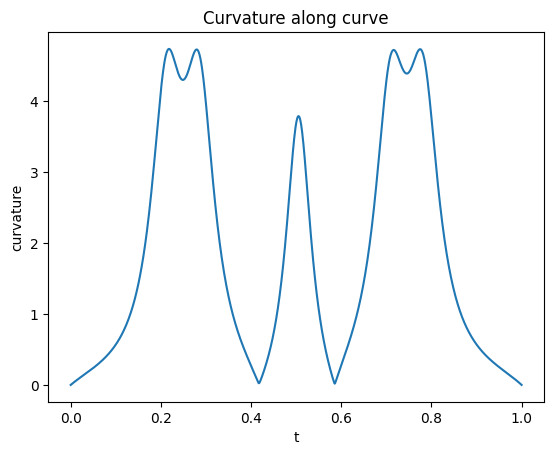

<Axes: title={'center': 'Curvature along curve'}, xlabel='t', ylabel='curvature'>

100%|█████████▉| 24998/25000 [14:10<00:00, 30.38it/s, Loss: 0.0856618583202362]

In [ ]:
print( tester.poly_z() )
tester.curve.plot_curvature()